In [1]:
import numpy as np
import pandas as pd
from time import time

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pandas import set_option
from sklearn.metrics import confusion_matrix

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report

from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

import seaborn as sns; sns.set() 

# Packages to perform dimensionality reduction
import sklearn.datasets
import sklearn.decomposition
import sklearn.manifold



# Packages for plotting
import mpl_toolkits.mplot3d
from matplotlib import offsetbox
import seaborn as sns
rc={'lines.linewidth': 2, 'axes.labelsize': 14, 'axes.titlesize': 14}
sns.set(rc=rc)

# load the data set
dataPath = "Data_Expression_mRNA_9classes.csv"
dataset = pd.read_csv(dataPath)#display the data set

In [2]:
# Display dataset information
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Columns: 3006 entries, Classes to gen3005
dtypes: int64(3006)
memory usage: 114.6 MB


In [3]:
# Display first few rows of dataset
dataset.head()

,Classes,gen1,gen2,gen3,gen4,gen5,gen6,gen7,gen8,gen9,...,gen2996,gen2997,gen2998,gen2999,gen3000,gen3001,gen3002,gen3003,gen3004,gen3005
0,1,0,0,0,3,0,0,3,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,3,1,0,2,2,2,2,1,0,...,0,0,0,0,0,0,0,0,0,1
2,1,3,1,6,4,1,2,1,0,5,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,1,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Display last few rows of dataset
dataset.tail()

,Classes,gen1,gen2,gen3,gen4,gen5,gen6,gen7,gen8,gen9,...,gen2996,gen2997,gen2998,gen2999,gen3000,gen3001,gen3002,gen3003,gen3004,gen3005
4993,9,1,0,0,0,0,0,0,0,5,...,0,0,0,0,0,0,0,0,1,2
4994,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4996,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,2,0
4997,9,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Count unique values in dataset
dataset.nunique()

Classes     9
gen1       69
gen2       65
gen3       79
gen4       89
           ..
gen3001    23
gen3002    21
gen3003    19
gen3004    24
gen3005    26
Length: 3006, dtype: int64

In [6]:
# Sum of null values in dataset
dataset.isnull().sum()

Classes    0
gen1       0
gen2       0
gen3       0
gen4       0
          ..
gen3001    0
gen3002    0
gen3003    0
gen3004    0
gen3005    0
Length: 3006, dtype: int64

In [7]:
# Split dataset into features (x) and target (y) 
x = dataset.drop("Classes", axis=1)
y = dataset["Classes"].values
# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

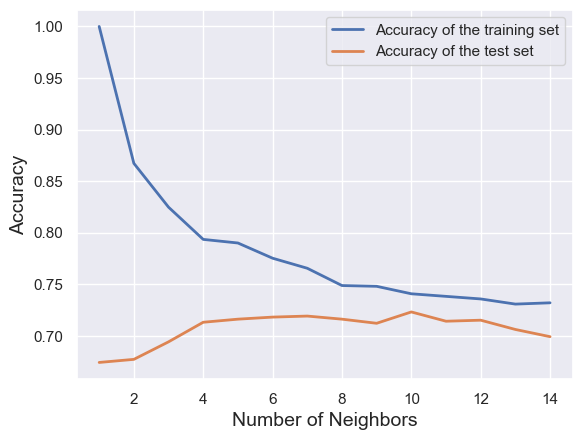

In [8]:
#Initialize empty lists to store training and test accuracies
#KNN with the unoptimized params
#----------KNN Classifier 


training_accuracy = []
test_accuracy = []

#try KNN for different k nearest neighbors from 1 to 15
neighbors_setting = range(1, 15)

#loop through each value of the number of neighbors
for n_neighbors in neighbors_setting:
    #initialize KNN classifier with the current number of neighbors
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    # train the classifier on the training data
    knn.fit(x_train, y_train)
    #compute and store data onto the training set
    training_accuracy.append(knn.score(x_train, y_train))
    #compute and store data onto the testing set
    test_accuracy.append(knn.score(x_test, y_test))

 #Plot the training and testing accuracies as a function of the number of neighbors
plt.plot(neighbors_setting, training_accuracy, label='Accuracy of the training set')
plt.plot(neighbors_setting, test_accuracy, label='Accuracy of the test set')
plt.ylabel('Accuracy')
plt.xlabel('Number of Neighbors')
plt.legend()
plt.show()
#by looking at plot, best result accurs when n_neighbors is 15

In [9]:
#print both accuracy of training and testing set
print("Accuracy of the training set for 7NN: {:.2f}".format(training_accuracy[6]))
print("Accuracy of the test set for 7NN: {:.2f}".format(test_accuracy[6]))

Accuracy of the training set for 7NN: 0.77
Accuracy of the test set for 7NN: 0.72


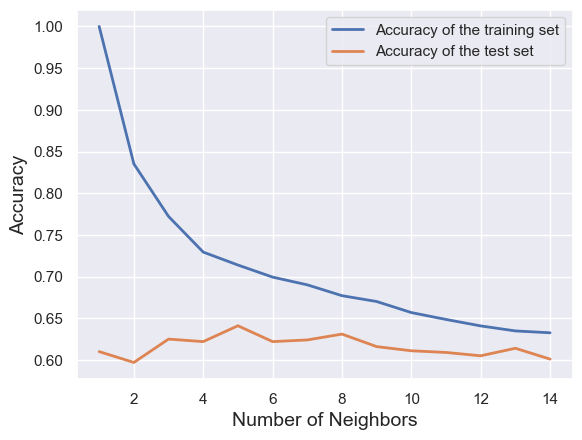

In [10]:
# 1- Scaling X data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#KNN optimized params
training_accuracy = []
test_accuracy = []

#try KNN for different k nearest neighbors from 1 to 15
neighbors_setting = range(1, 15)

#loop through each values in neighbors
for n_neighbors in neighbors_setting:
    #initialize KNN classifier with the current number of neighbors
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    # train the classifier on the training data
    knn.fit(x_train_scaled, y_train)
    #compute and store data onto the training set
    training_accuracy.append(knn.score(x_train_scaled, y_train))
    #compute and store data onto the testing set
    test_accuracy.append(knn.score(x_test_scaled, y_test))

#Plot the training and testing accuracies as a function of the number of neighbors
plt.plot(neighbors_setting, training_accuracy, label='Accuracy of the training set')
plt.plot(neighbors_setting, test_accuracy, label='Accuracy of the test set')
plt.ylabel('Accuracy')
plt.xlabel('Number of Neighbors')
plt.legend()
plt.show()
#by looking at plot, best result accurs when n_neighbors is 15

In [11]:
#print Both accuracy of training and testing set
print("Accuracy of the training set for 7NN: {:.2f}".format(training_accuracy[6]))
print("Accuracy of the test set for 7NN: {:.2f}".format(test_accuracy[6]))

Accuracy of the training set for 7NN: 0.69
Accuracy of the test set for 7NN: 0.62


In [12]:
# Import necessary libraries
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# Make predictions on validation dataset
# Initialize K-Nearest Neighbors classifier with optimized parameters
KNN = KNeighborsClassifier(n_neighbors = 14)
KNN.fit(x_train_scaled, y_train)# Train the classifier on the scaled training data
predictions = KNN.predict(x_test_scaled)# Make predictions on the scaled testing data
print('Predicted accuracy: %.2f%%\n' % (100*accuracy_score(y_test, predictions)))# Print the predicted accuracy
print(confusion_matrix(y_test, predictions))# Print the confusion matrix
print('')
print(classification_report(y_test, predictions))# Print the classification report

Predicted accuracy: 60.10%

[[161   2  13  41   6   3   3  10   2]
 [ 16  20   3  20   1   1   2   3   0]
 [ 83   6 172  32   3   6   1  13   2]
 [  2   0   0  89   4   3   4   7   0]
 [  1   0   0  29  49   0   0   1   0]
 [  1   0   0  22   0  55   0   2   2]
 [  1   0   0  18   3   1  19   2   0]
 [  0   0   0  13   0   1   0  27   0]
 [  0   0   0   8   0   2   0   0   9]]

              precision    recall  f1-score   support

           1       0.61      0.67      0.64       241
           2       0.71      0.30      0.43        66
           3       0.91      0.54      0.68       318
           4       0.33      0.82      0.47       109
           5       0.74      0.61      0.67        80
           6       0.76      0.67      0.71        82
           7       0.66      0.43      0.52        44
           8       0.42      0.66      0.51        41
           9       0.60      0.47      0.53        19

    accuracy                           0.60      1000
   macro avg       0.64

In [13]:
#Logistic Regression
#without parameter optimization
# Split data into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize Logistic Regression classifier
clf = LogisticRegression(max_iter = 10000)

# Train the classifier on the training data
clf.fit(x_train,y_train)

# Compute the confusion matrix on the testing data
conf_te = confusion_matrix(y_test, clf.predict(x_test))

# Define a function to calculate accuracy
def accuracy(conf):
    total_correct = 0.
    nb_classes = conf.shape[0]
    for i in np.arange(0,nb_classes):
        total_correct += conf[i][i]
    acc = total_correct/sum(sum(conf))
    return acc

# Print the predicted accuracy
print('Predicted accuracy: %.2f%%\n' % (100*accuracy(conf_te),))

# Predict labels for the testing data
print(conf_te)
predicted_labels = clf.predict(x_test)

Predicted accuracy: 87.70%

[[196   6  30   2   2   0   4   1   0]
 [ 14  43   5   2   0   1   0   1   0]
 [ 19   4 292   2   0   1   0   0   0]
 [  1   1   0 105   1   0   0   1   0]
 [  0   0   0   0  79   1   0   0   0]
 [  0   0   0   1   0  78   1   0   2]
 [  3   0   1   2   0   1  36   1   0]
 [  1   0   0   1   0   4   0  34   1]
 [  0   0   0   0   0   4   0   1  14]]


In [14]:
# Initialize StandardScaler and scale the features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Initialize Logistic Regression classifier with parameter optimization
clf = LogisticRegression(max_iter = 10000)
clf.fit(x_train_scaled,y_train)
conf_te = confusion_matrix(y_test, clf.predict(x_test_scaled))

# Train the classifier on the scaled training data 
# Define a function to calculate accuracy
def accuracy(conf):
    total_correct = 0.
    nb_classes = conf.shape[0]
    for i in np.arange(0,nb_classes):
        total_correct += conf[i][i]
    acc = total_correct/sum(sum(conf))
    return acc

# Compute the confusion matrix on the scaled testing data
# Print the predicted accuracy
print('Predicted accuracy: %.2f%%\n' % (100*accuracy(conf_te),))
print(conf_te)# Print the confusion matrix
predicted_labels = clf.predict(x_test_scaled)# Predict labels for the scaled testing data

Predicted accuracy: 85.30%

[[195   5  29   2   4   0   4   1   1]
 [ 16  39   8   1   1   0   0   1   0]
 [ 21   2 288   0   3   1   0   1   2]
 [  3   0   0  98   2   3   1   2   0]
 [  0   0   0   0  76   2   1   1   0]
 [  1   0   0   2   0  78   1   0   0]
 [  2   0   1   3   3   3  31   1   0]
 [  0   0   1   1   0   2   0  36   1]
 [  0   0   0   0   0   6   1   0  12]]


When applying KNN to the unoptimized data frame, the optimal training and testing accuracies are 0.77 and 0.72, respectively. However, upon optimizing the data frame through standardization, both the training and testing accuracies decrease to 0.69 and 0.62, respectively. This reduction suggests potential information loss during the scaling process.

Regarding Logistic Regression (LR):
The initial predicted accuracy without optimization is 87.70%. Upon standardizing the data, the predicted accuracy diminishes to 85.30%. This decrease in accuracy post-optimization indicates a potential loss of information during the scaling process.

The unoptimized KNN model demonstrates superior performance in terms of accuracy compared to the optimized counterpart, as evidenced by higher training and testing accuracy scores.


# 